**Imports**

In [98]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay

**Deliverable 1: Data Loading and Preprocessing**

In [99]:
#load csv file (step 1.1)
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [100]:
# checking if my virtul env is set up correctly
# had to have python 3.11 as kernel bc tensor flow doesn't run on more updated versions of python
print(sys.executable)
print(sys.version)

/Users/fionac./nlpcv/tf-venv/bin/python
3.11.4 (v3.11.4:d2340ef257, Jun  6 2023, 19:15:51) [Clang 13.0.0 (clang-1300.0.29.30)]


In [101]:
num_classes = 25
# 24 classes (a-z excluding j&z)
input_shape = (28, 28, 1)
# 28 by 28 pixels, one channel bc grayscale image

#split train and test sets
y_train = train_df["label"].values
x_train = train_df.drop("label", axis=1).values

y_test = test_df["label"].values
x_test = test_df.drop("label", axis=1).values

#normalize values (scales to [0,1]) (step 1.2)
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

#reshape 
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

#ensuring images have correct shape (they do!)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


x_train shape: (27455, 28, 28, 1)
27455 train samples
7172 test samples


In [102]:
# creating validation split from train set (1.3)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
# stratify with y_train to make sure class distribution matches original dataset?
print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (21964, 28, 28, 1)
Val: (5491, 28, 28, 1)
Test: (7172, 28, 28, 1)


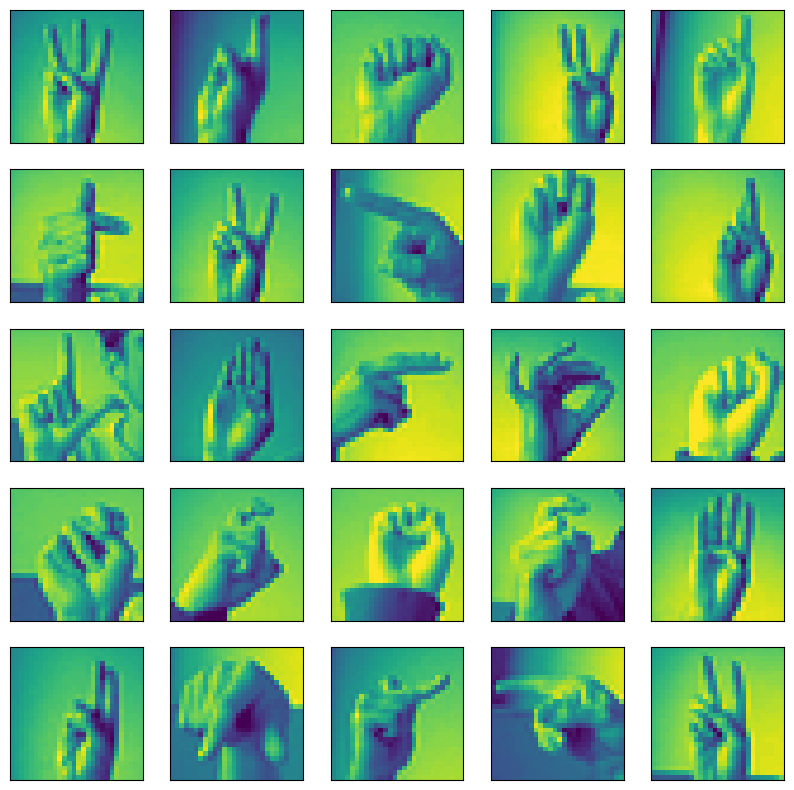

In [103]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_train[i,:,:,:]))
plt.show()
# view samples of ASL signs

**Deliverable 2: CNN Architectures**

In [104]:
#baseline cnn (step 2.1)
# # changed second 32 to 64, because that pattern in past workshops worked better 
# model = tf.keras.Sequential(
#     [
#         tf.keras.Input(shape=input_shape),
#         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#         layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#         layers.MaxPooling2D(pool_size=(2, 2)),
#         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#         layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#         layers.MaxPooling2D(pool_size=(2, 2)),
#         layers.Flatten(),
#         layers.Dropout(0.5),
#         layers.Dense(num_classes, activation="softmax"),

#     ]
# )
# model.summary()

In [117]:
#vggnet model
model = tf.keras.Sequential(
    [
        # first block
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        # 3,3 kernel is small enough to capture details of this dataset
        # padding =same keeps the output at 28,28 size so spatial info isn't lost
        # relu sets any negative values to zero; nonlinearity
        #regularization helps overfitting
        layers.BatchNormalization(),
        # normalizes output for each batch;stabilizes training
        layers.Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        # second block
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        #decided only to do 2 blocks because dataset isn't very large, so going super deep in layers wouldn't benefit this model
        # model with simplifying layers starting at 16 instead of 32 ran in around 4 minutes, while before it was running in 6-7 mins"

        layers.Flatten(),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),

    ]
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,049 (465.04 KB)

 Trainable params: 118,729 (463.79 KB)

 Non-trainable params: 320 (1.25 KB)

**Deliverable 3: Training, Testing, and Evaluation**

In [106]:
from keras.optimizers import Adam

# Available optimizers
# SGD
# RMSprop
# Adam
# AdamW
# Adadelta
# Adagrad
# Adamax
# Adafactor
# Nadam
# Ftrl

batch_size = 128
epochs = 15

#Adm = Adam(lr=0.1)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [107]:
early = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)
# stops training when val loss starts increasing
history = model.fit(x_train, y_train, batch_size=128, epochs=25, validation_data=(x_val, y_val), callbacks=early)
#baseline model with batch size of 128 and epochs of 100 took 21 mins to run

Epoch 1/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.5965 - loss: 1.4754 - val_accuracy: 0.0370 - val_loss: 4.3107
Epoch 2/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9221 - loss: 0.3668 - val_accuracy: 0.1258 - val_loss: 3.5250
Epoch 3/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.9744 - loss: 0.1651 - val_accuracy: 0.8926 - val_loss: 0.4865
Epoch 4/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9874 - loss: 0.0979 - val_accuracy: 0.9989 - val_loss: 0.0435
Epoch 5/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9933 - loss: 0.0691 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 6/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9955 - loss: 0.0550 - val_accuracy: 1.0000 - val_loss: 0.0237
Epoch 7/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9962 - loss: 0.0471 - val_accuracy: 1.0000 - val_loss: 0.0233
Epoch 8/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9978 - loss: 0.0396 - 

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
# baseline model had test loss of 0.93 and test acc of 0.84
# new model had test loss of 1.23 and test acc of 0.88
# adding drop out helped so much! 0.94 accuracy and test loss of 0.33 (0.3 dropout)
# even better with 0.5 dropout! 0.96 acc and test loss of 0.18
# 0.97 acc with adding 0.0001 l2 regularization
# 0.973 acc and .136 test loss woith dropout of 0.3!

Test loss: 0.13689713180065155
Test accuracy: 0.9732292294502258


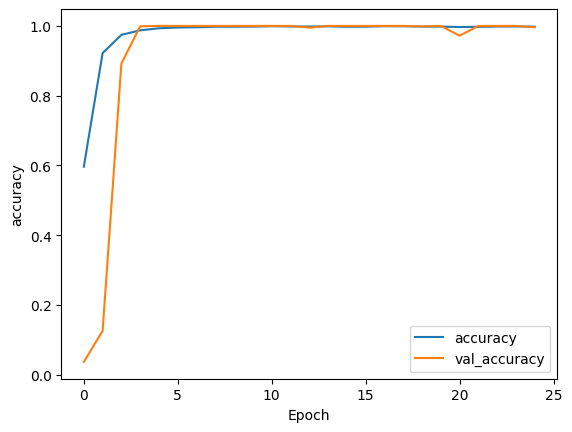

225/225 - 1s - 4ms/step - accuracy: 0.9732 - loss: 0.1369


In [109]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

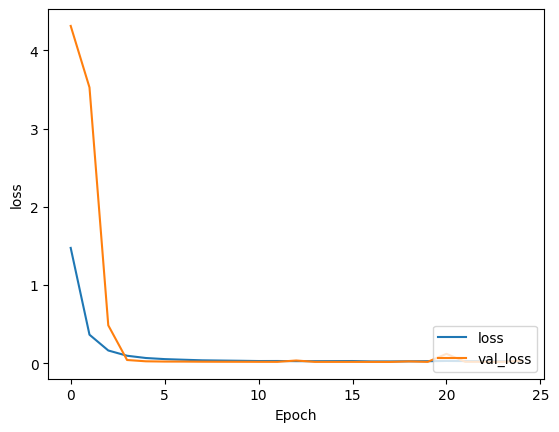

In [110]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend(loc='lower right')
plt.show()

**Deliverable 3: Training, Testing, and Evaluation**

In [111]:
y_pred_probs = model.predict(x_test)
# gives probs
y_pred_labels = np.argmax(y_pred_probs, axis=1)
# predicted class labels

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [112]:
print(y_test[:5])

[ 6  5 10  0  3]


In [113]:
from sklearn.metrics import classification_report
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_labels))
print("\nClassification report:")
print(classification_report(y_test, y_pred_labels))

Confusion matrix:
[[331   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0 432   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0 310   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0 245   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0 498   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0 247   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0 348   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0  25 411   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 288   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 310   0   0   0   0   0   0  21   0

In [114]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
prec = precision_score(y_test, y_pred_labels, average="macro")
print("Precision score:", prec)
rec = precision_score(y_test, y_pred_labels, average="macro")
print("Recall score:", rec)
f1 = f1_score(y_test, y_pred_labels, average="macro")
print("F1 score:", f1)


Precision score: 0.9709010697068708
Recall score: 0.9709010697068708
F1 score: 0.9708871596317987


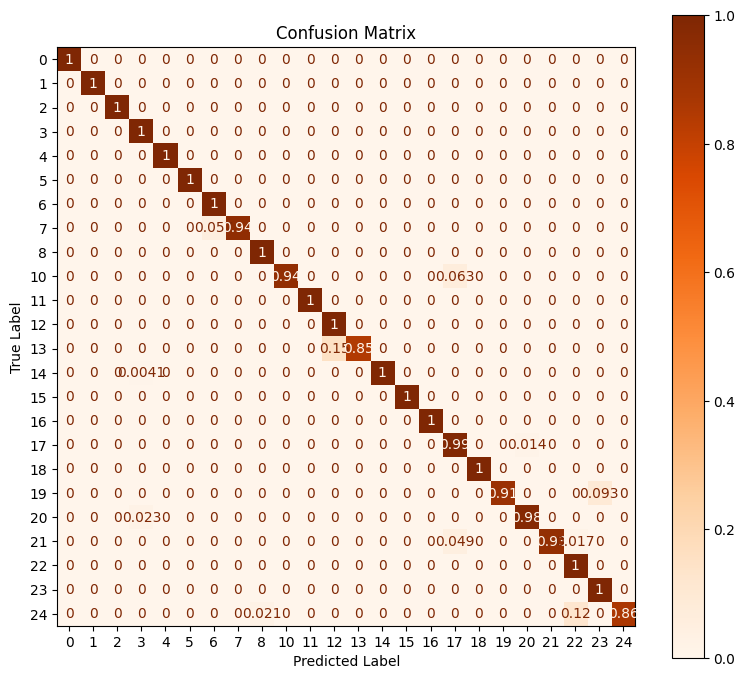

In [115]:
from sklearn.metrics import ConfusionMatrixDisplay

labels = np.unique(y_test)

cm = confusion_matrix(y_test, y_pred_labels, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8,7))
disp.plot(cmap='Oranges', colorbar=True, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()


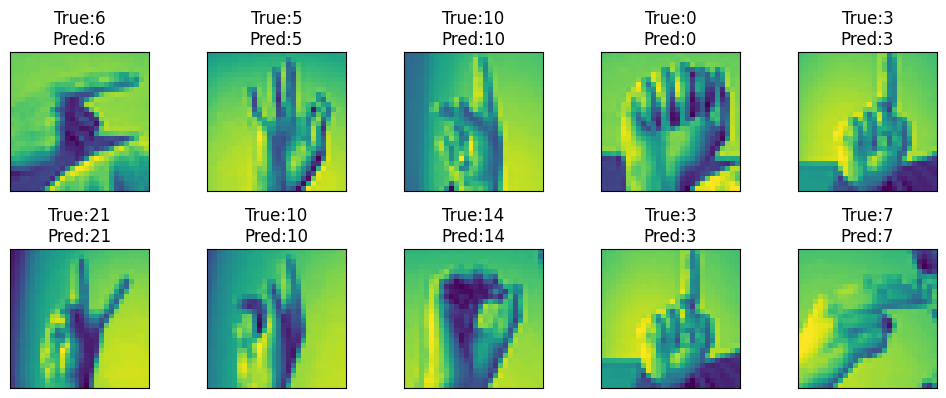

In [116]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_test[i,:,:,:]))
    plt.title(f"True:{y_test[i]}\nPred:{y_pred_labels[i]}")
    plt.tight_layout()
plt.show()